# K-Means Clustering is an Unsupervised Learning algorithm, which groups the unlabeled dataset into different clusters.
# K defines the number of pre-defined clusters that need to be created in the process.

# Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Import dataset (using Iris dataset)

In [2]:
dataset = pd.read_csv("/Users/bhavyakansal/Datasets/iris.csv")
dataset.head(3)

,sepal_lenght,sepal_width,petal_lengh,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


# Let's make it unsupervised by droping the output column 

In [3]:
dataset.drop(columns=["Species"] , inplace= True)
dataset.head(10)

,sepal_lenght,sepal_width,petal_lengh,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


# Lets identify realtionship between data in graphical form to check whether the data is linear separable or not because K Means clustering works best on linear data 

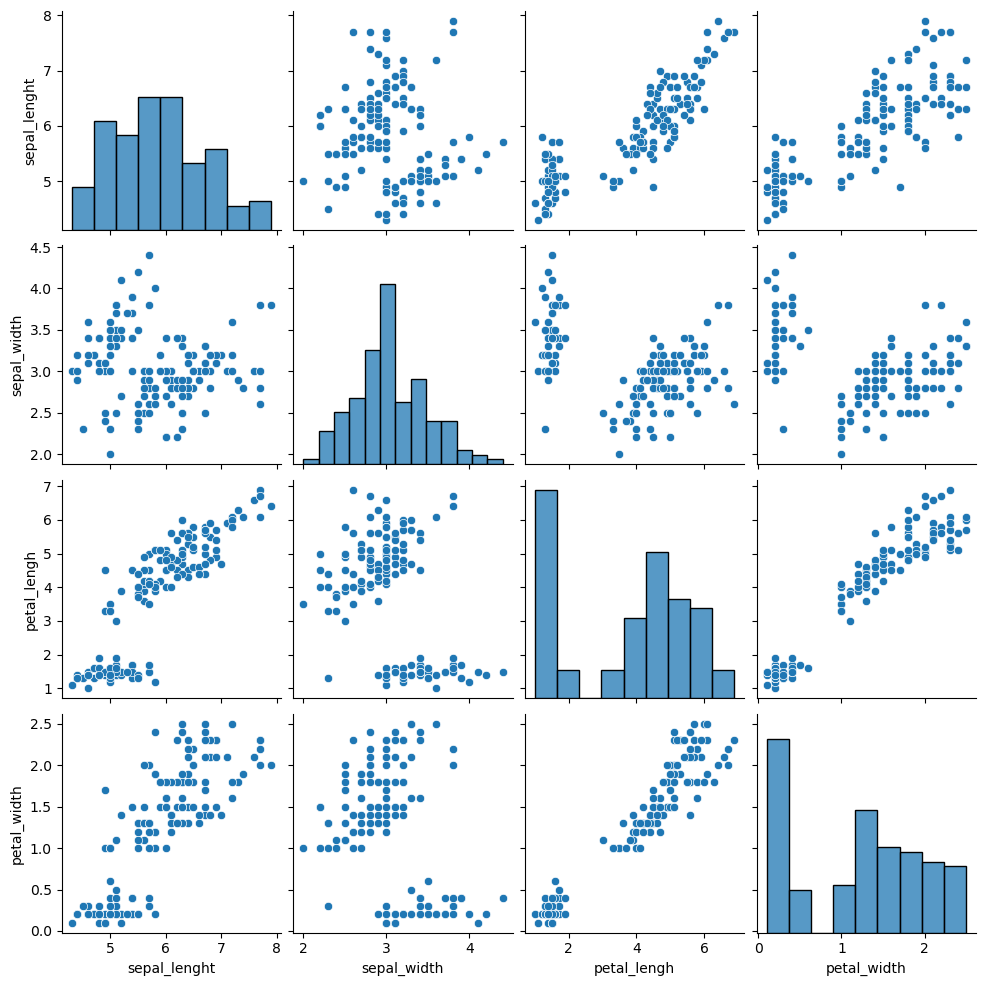

In [4]:
sns.pairplot(data=dataset)
plt.show()

# As we can see our data break in two parts but we know that iris data have three clustures : Setosa  , verginica  , vercicolor . so to find out that K means clusturing helps us to do so 

# In unsupervised Learning we dont split data into Train and Test because we dont have output like in supervised we have both input and output so we split train and then test our model , But in unsupervised we do pattern recognisation and then divide our data into small groups to have output  

# Now Let's find out best no of clustures and for that we use Sklearn because we need WCSS (within a cluster sum square) methord means in short we will use Elbow methord to do so

In [5]:
from sklearn.cluster import KMeans

In [6]:
wcss = []

for i in range (2,21):
    km = KMeans(n_clusters= i , init="k-means++")
    km.fit(dataset)
    wcss.append(km.inertia_)

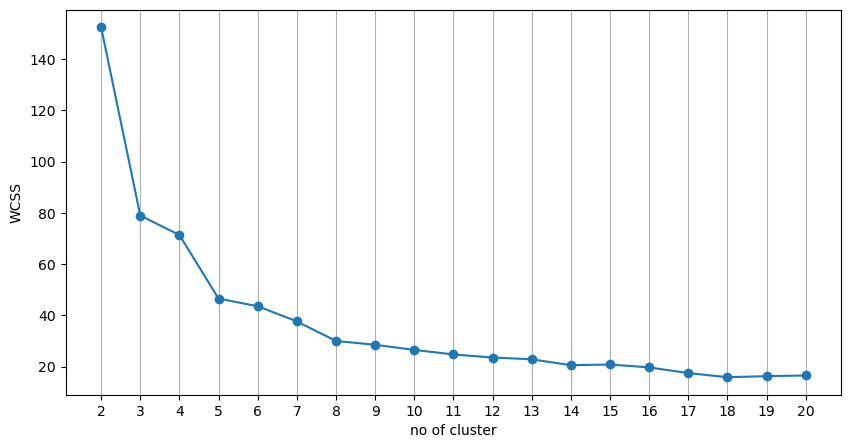

In [20]:
plt.figure(figsize=(10,5))
plt.plot(range(2, 21), wcss , marker="o")
plt.xlabel("no of cluster")
plt.xticks(range(2, 21))
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()

# If we see the above graph we can clearly see at the point 3 the graph is going downwards and making an elbow like sutructure so we have to design 3 cluster.  
# Also here we can also see 3 and 4 are somehow similar point no major downfall so we can take any point as best point according to your dataset

In [29]:
kmn = KMeans(n_clusters=3)
dataset["Predict"] = kmn.fit_predict(dataset)

In [24]:
dataset.head(10)

,sepal_lenght,sepal_width,petal_lengh,petal_width,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


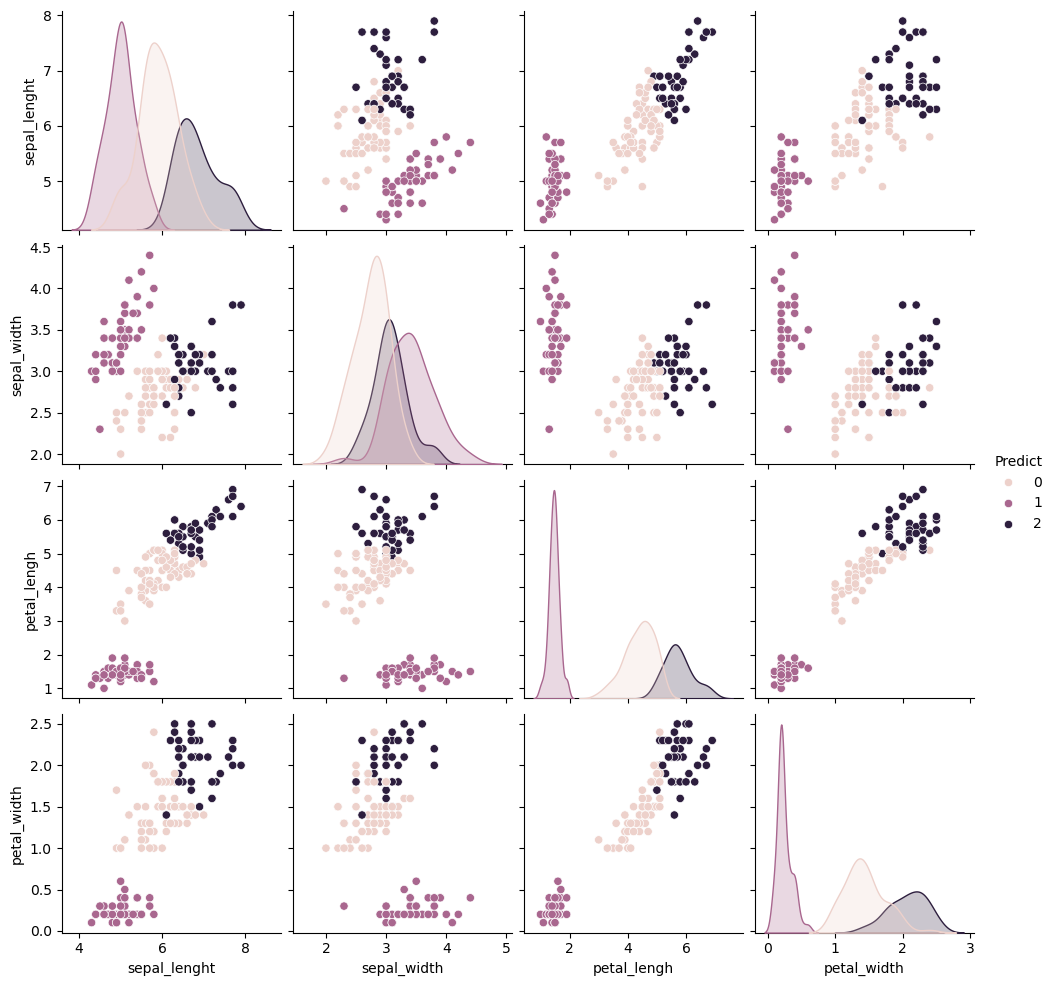

In [42]:
sns.pairplot(data= dataset , hue="Predict")
plt.savefig("Predict.jpg")
plt.show()

# Now lets Compare it with our original Iris Dataset that how original data is designing it's cluster to check weather we have done correct or not 

In [43]:
org_dataset = pd.read_csv("/Users/bhavyakansal/Datasets/iris.csv")
org_dataset.head(3)

,sepal_lenght,sepal_width,petal_lengh,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


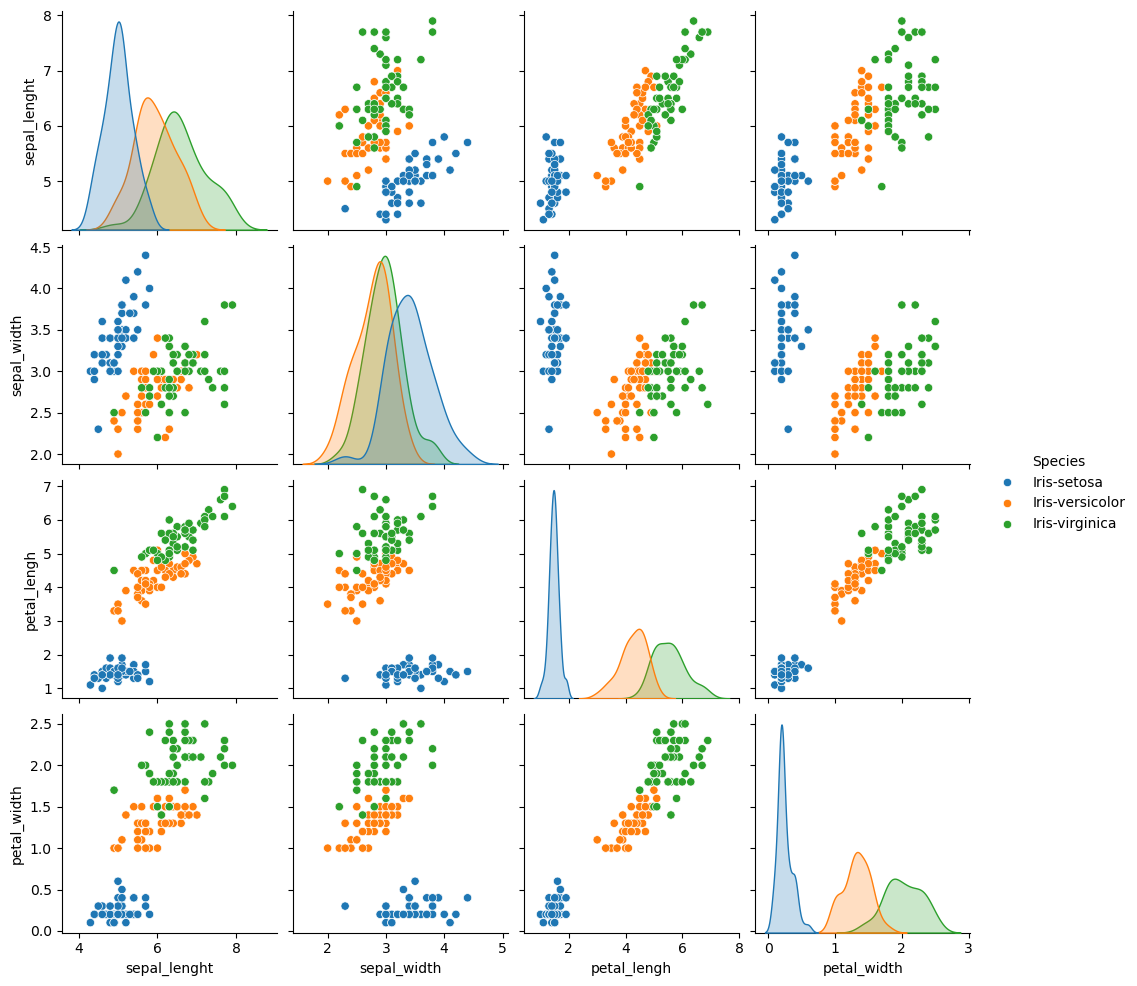

In [45]:
sns.pairplot(data =org_dataset , hue="Species")
plt.savefig("ORG.jpg")
plt.show()